# Learning from Examples: Line Fitting

We want to fit a straight line to data (i.e., perform linear regression). The general approach is applicable to other model classes as well.

We will compare:

* Grid search over the loss function
* The analytical solution
* Gradient descent
* Stochastic gradient descent (SGD with mini-batches)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()

## Simulate some data with noise

**Unknown function:** $y = f(x) = w_0 + w_1x + N(0,1)$ with $w_0 = 3$ and $w_1 = 7$

In [2]:
def f(x, w0, w1): 
    return w0 + w1 * x + rng.normal(loc=0.0, scale=1.0, size=len(x))

Simulate 100 examples $(x, y)$. We choose for each example randomly (uniform) $x \in [0,1]$ and calculate the noisy value for $y$ using $f(x)$.

In [3]:
N = 1000
real_w0 = 3
real_w1 = 7

In [4]:
x = rng.uniform(0, 1, N)
y = f(x, real_w0, real_w1)

In [5]:
xy = pd.DataFrame({ 'x':x, 'y':y})
xy

,x,y
0,0.449125,5.934818
1,0.305625,5.178255
2,0.112210,3.626886
3,0.661571,8.011343
4,0.711656,5.731319
...,...,...
995,0.925902,8.918194
996,0.979976,8.530102
997,0.335706,6.311936
998,0.117776,2.983740


Plot the noisy simulated data and add the real function $f(x)$ without the noise term as a line.

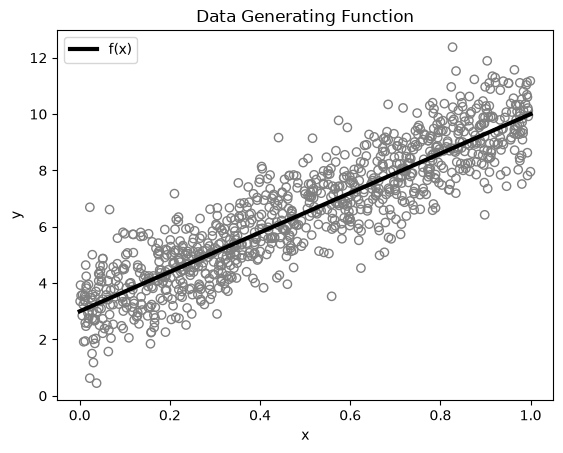

In [6]:
def plot_data(xy, title = ""): 
    plt.figure()
    plt.scatter(xy['x'], xy['y'], edgecolors='grey', facecolors='none')
    x_line = np.linspace(0, 1, 100)
    y_line = real_w0 + real_w1 * x_line
    plt.plot(x_line, y_line, color='black', linewidth=3, label='f(x)')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.legend()
    
    return plt

plt = plot_data(xy, "Data Generating Function")

## Define the Hypothesis Space and the Loss Function

### Hypothesis space: Line equations 

$h_w(x) = h(x ; \mathbf{w}) = \hat{y} = w_0 + w_1 x$

In [7]:
def y_hat(x, w0, w1):
    return w0 + w1 * x

### Empirical Loss: Squared-error loss (L2)

$Loss(\mathbf{w}) = || \mathbf{X}\mathbf{w} - \mathbf{y} ||^2 = \sum_{j=1}^N (y_j - h_w(x_j))^2$

In [8]:
def L2(y, y_hat): 
    return np.sum((y - y_hat)**2)

## Grid search

Create a grid of w0 and w1 values

In [9]:
resolution = 25

# Create grid (equivalent to R's expand.grid)
w0_vals = np.linspace(0, 10, resolution)
w1_vals = np.linspace(0, 10, resolution)

grid = pd.DataFrame({
    "w0": np.repeat(w0_vals, resolution),
    "w1": np.tile(w1_vals, resolution)
})

grid

,w0,w1
0,0.0,0.000000
1,0.0,0.416667
2,0.0,0.833333
3,0.0,1.250000
4,0.0,1.666667
...,...,...
620,10.0,8.333333
621,10.0,8.750000
622,10.0,9.166667
623,10.0,9.583333


In [10]:
# Compute L2 for each row in grid
def compute_L2(row):
    return L2(xy["y"], y_hat(xy["x"], row["w0"], row["w1"]))

In [11]:
grid["L2"] = grid.apply(compute_L2, axis=1)
grid

,w0,w1,L2
0,0.0,0.000000,47328.682664
1,0.0,0.416667,44209.808295
2,0.0,0.833333,41205.371392
3,0.0,1.250000,38315.371956
4,0.0,1.666667,35539.809986
...,...,...,...
620,10.0,8.333333,59473.297040
621,10.0,8.750000,62778.218943
622,10.0,9.166667,66197.578313
623,10.0,9.583333,69731.375149


In [12]:
opt = grid.loc[[grid["L2"].idxmin()]]
opt

,w0,w1,L2
192,2.916667,7.083333,987.295594


Plot loss function surface

In [13]:
def loss_surface_plot(grid):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    #ax.view_init(elev=30, azim=45)

    resolution = int(len(grid) ** .5)
    Z = grid["L2"].values.reshape((resolution, resolution)).transpose()

    W0, W1 = np.meshgrid(np.linspace(0, 10, resolution), 
                         np.linspace(0, 10, resolution))

    ax.plot_surface(W0, W1, Z, alpha=0.7)

    ax.set_xlabel("w0")
    ax.set_ylabel("w1")
    ax.set_zlabel("loss")

    return ax

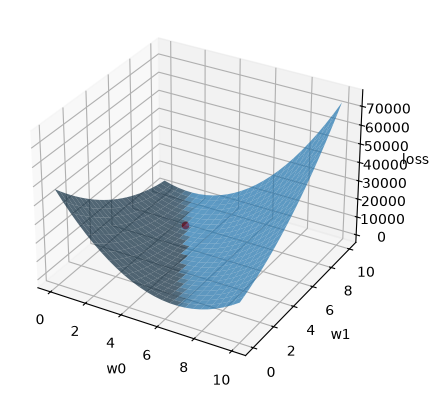

In [14]:
ax = loss_surface_plot(grid)

ax.scatter(
    opt["w0"],
    opt["w1"],
    opt["L2"],
    color="red",
    s=20
)

plot regression line

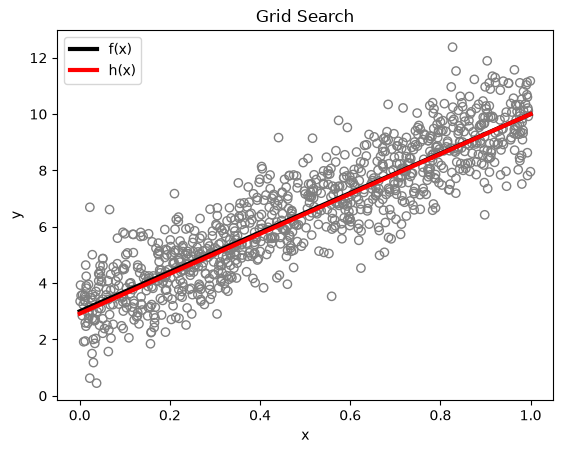

In [15]:
plot_data(xy, "Grid Search")

x_line = np.linspace(0, 1, 100)
y_line = y_hat(np.asarray(x_line), opt["w0"].item(), opt["w1"].item())
plt.plot(x_line, y_line, color='red', linewidth=3, label='h(x)')

plt.legend()

## Analytical solution

Loss is minimized by setting the gradient of the loss function to 0.

$\frac{\partial Loss}{\partial w_1}(w) = 0$ and $\frac{\partial Loss}{\partial w_0}(w) = 0$

Solution:

$w_1 = \frac{N\left(\sum x_j y_j \right) - \left(\sum x_j \right)\left(\sum y_j\right)}{N \left(\sum x_j^2 \right) - \left(\sum x_j \right)^2}$

$w_0 = \frac{\sum y_j - w_1 \left(\sum x_j \right)}{N}$

Note: If you want to check the solution, then you can take the gradient (calculated in the next section below), set it to zero and solve for $w_0$ and $w_1$.

In [16]:
x = xy["x"]
y = xy["y"]
N = len(x)

w1 = (N * np.sum(x * y) - np.sum(x) * np.sum(y)) / \
     (N * np.sum(x**2) - (np.sum(x))**2)

w0 = (y.sum() - w1 * x.sum()) / N

print(f"w0: {w0}, w1: {w1}")

w0: 2.9965128780307744, w1: 7.05269080718193


The parameters are not exact because of the noise!

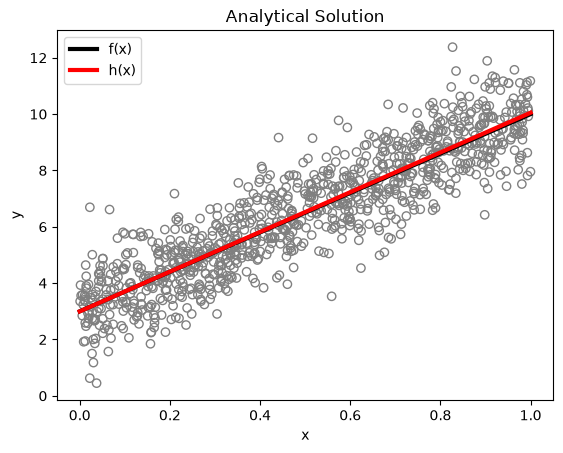

In [17]:
plot_data(xy, "Analytical Solution")

x_line = np.linspace(0, 1, 100)
y_line = y_hat(np.asarray(x_line), w0, w1)
plt.plot(x_line, y_line, color='red', linewidth=3, label='h(x)')

plt.legend()

## Gradient descent

This is the minimization analog to hill climbing. The algorithm starts with a point in the search space. It  estimates the gradient in that point and moves a small step in the steepest downhill direction. This is repeated until it converges on a point representing a (local) minimum loss. 

The update step is

$$w_i \leftarrow w_i - \alpha \frac{\partial Loss}{\partial w_i}(\mathbf{w})$$

where $\alpha$ is called the step size and $\mathbf{w}$ is the current location. The step size can be fixed (a hyperparameter) or we can decrease it over time. 
Starting with the empircal loss function

$Loss(\mathbf{w}) = \sum_{j=1}^N (y_j - h(x_j;\mathbf{w}))^2$ with $h(x; \mathbf{w}) = w_0 + w_1 x$

we get the gradient

$\frac{\partial Loss}{\partial w_i}(\mathbf{w}) = \frac{\partial \sum_{j=1}^N (y_j - h(x_j;\mathbf{w}))^2}{\partial w_i}$

The partial derivatives can be found using the [chain rule](https://en.wikipedia.org/wiki/Chain_rule) 
where a composition of two functions $f(x)=z(y(x))$ leads to $f'(x) = z'(y(x)) y'(x)$ ($z$ is here the square).
For $w_1$ we get:

$\frac{\partial \sum_{j=1}^N (y_j - h(x_j;\mathbf{w}))^2}{\partial w_1} = 
 \frac{\partial \sum_{j=1}^N (y_j - (w_0 + w_1 x_j))^2}{\partial w_1} =
 2 \sum_j^N(y_j - (w_0 + w_1 x_j))x_j =
 2 \sum_j^N(y_j - h(x_j;\mathbf{w}))x_j $

The factor of 2 gets absorbed into $\alpha$ and we get for $w_0$ and $w_1$ the following update rules:

$$w_0 \leftarrow w_0 + \alpha \sum_j(y_j - h(x_j;\mathbf{w}))$$
$$w_1 \leftarrow w_1 + \alpha \sum_j(y_j - h(x_j;\mathbf{w}))x_j$$

_Notes:_ $L_2$ loss makes sure that 
* The loss function is differentiable and we can determine the gradient.
* The loss function for linear regression is convex which means that there are no local minima.

### Batch gradient descent

Update by calculating the gradient over all the training data.

In [18]:
from tqdm import tqdm

def line_BGD(xy, alpha=0.0001, epochs=1000):
    
    # initialize weights
    w0 = 0.0
    w1 = 0.0
    
    x = xy["x"]
    y = xy["y"]
    
    # initial loss
    history = [{
        "w0": w0,
        "w1": w1,
        "loss": L2(y, y_hat(x, w0, w1))
    }]
    
    for step in tqdm(range(epochs)):
        
        # predictions
        y_pred = y_hat(x, w0, w1)
        
        # gradients (same as your R update form)
        w0 = w0 + alpha * np.sum(y - y_pred)
        w1 = w1 + alpha * np.sum((y - y_pred) * x)
        
        # store history
        history.append({
            "w0": w0,
            "w1": w1,
            "loss": L2(y, y_hat(x, w0, w1))
        })
    
    history = pd.DataFrame(history)
    
    return {
        "w": {"w0": w0, "w1": w1},
        "history": history
    }

In [19]:
opt = line_BGD(xy) 
opt

100%|██████████| 1000/1000 [00:00<00:00, 3478.71it/s]


{'w': {'w0': np.float64(2.9995333503118213),
  'w1': np.float64(7.047005235057932)},
 'history':             w0        w1          loss
 0     0.000000  0.000000  47328.682664
 1     0.649610  0.381131  36699.181588
 2     1.215347  0.717467  28581.756136
 3     1.707821  1.014646  22381.719295
 4     2.136301  1.277593  17645.178367
 ...        ...       ...           ...
 996   2.999614  7.046853    983.041718
 997   2.999594  7.046891    983.041680
 998   2.999574  7.046929    983.041643
 999   2.999553  7.046967    983.041606
 1000  2.999533  7.047005    983.041569
 
 [1001 rows x 3 columns]}

Learning curve

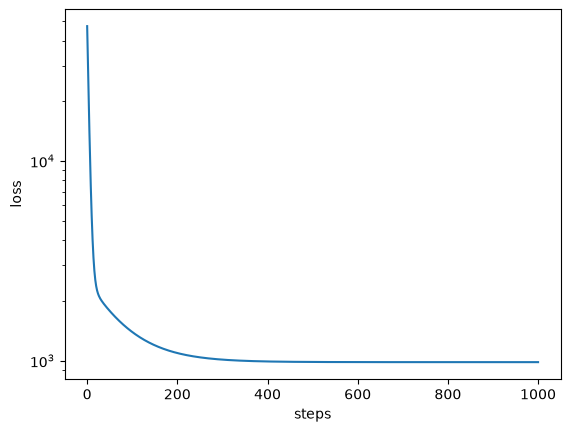

In [20]:
loss = opt["history"]["loss"]

plt.plot(loss)
plt.xlabel("steps")
plt.ylabel("loss")
plt.yscale("log") 

plt.show()

Detailed plot for the last 500 epochs.

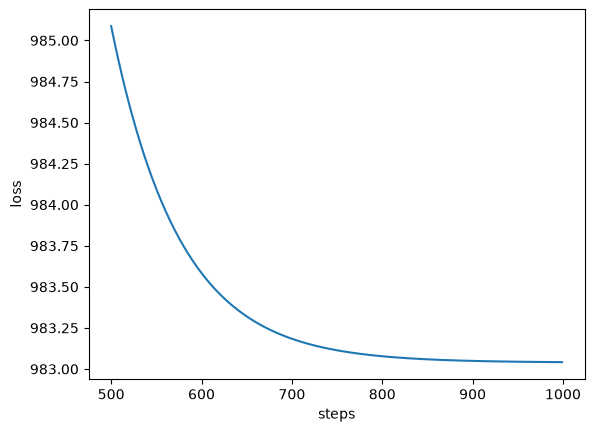

In [21]:
steps = range(500, 1000)
loss_slice = opt["history"]["loss"].iloc[500:1000]

plt.plot(steps, loss_slice)
plt.xlabel("steps")
plt.ylabel("loss")

plt.show()

Learning path

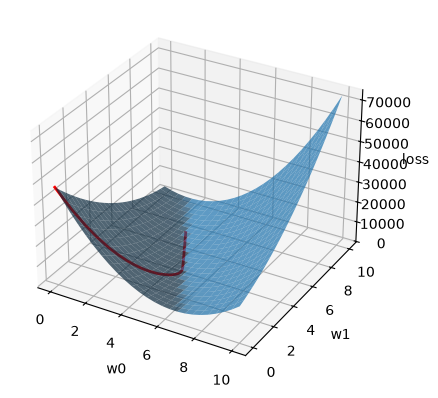

In [22]:
ax = loss_surface_plot(grid)

history = opt["history"]

ax.plot(
    history["w0"],
    history["w1"],
    history["loss"],
    color="red",
    linewidth=2
)

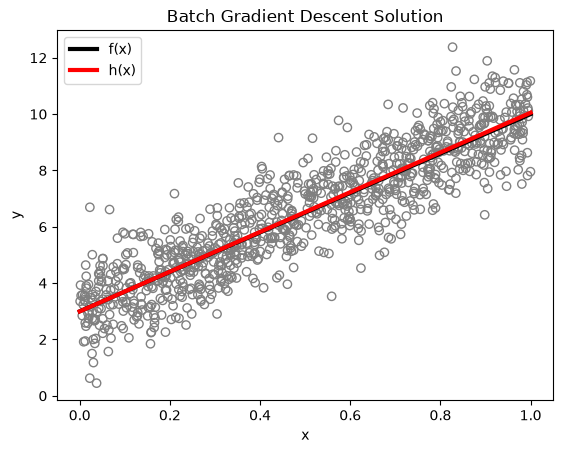

In [23]:
plot_data(xy, "Batch Gradient Descent Solution")

x_line = np.linspace(0, 1, 100)
y_line = y_hat(np.asarray(x_line), w0, w1)
plt.plot(x_line, y_line, color='red', linewidth=3, label='h(x)')

plt.legend()

### Stochastic gradient descent with minibatch

Regular gradient descent is expensive since it always caclulates the gradient over all data. For non-convex problems, batch gradient descent also can land you on a saddle point.

This can be overcome with stochastic gradient descend (SGD). Pure SGD calculates the gradient every time on a single randomly choosen data point. This leads to a very 
noisy gradient which helps with escaping from saddle points or local minima. If more than one points are choosen, then the gradient estimate becomes more stable. The number of points used is a hyperparameter called the _minibatch size._

In each episode, the algorithm randomly splits the data into minibatches and then 
performs one update on each minibatch. Because of more updates, typically fewer epochs are needed. 

In [24]:
from tqdm import tqdm

def line_SGD(xy, batch_size = 16, alpha = 0.001, epochs=200):
    
    # initialize weights
    w0 = 0.0
    w1 = 0.0
    
    x = xy["x"]
    y = xy["y"]
    
    # initial loss
    history = [{
        "w0": w0,
        "w1": w1,
        "loss": L2(y, y_hat(x, w0, w1))
    }]
    
    for step in tqdm(range(epochs)):
        
        # shuffle data each epoch
        indices = np.random.permutation(N)
        x_shuffled = x[indices]
        y_shuffled = y[indices]
        
        # iterate over mini-batches
        for i in range(0, N, batch_size):
            x_batch = x_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            y_pred = y_hat(x_batch, w0, w1)
            
            # update weights using batch
            w0 += alpha * np.sum(y_batch - y_pred)
            w1 += alpha * np.sum((y_batch - y_pred) * x_batch)
        
        # track full loss (not just batch loss)
        history.append({
            "w0": w0,
            "w1": w1,
            "loss": L2(y, y_hat(x, w0, w1))
        })

        # predictions
        y_pred = y_hat(x, w0, w1)
    
    history = pd.DataFrame(history)
    
    return {
        "w": {"w0": w0, "w1": w1},
        "history": history
    }

In [25]:
opt = line_SGD(xy) 
opt

100%|██████████| 200/200 [00:02<00:00, 76.27it/s]


{'w': {'w0': np.float64(2.9932180562201434),
  'w1': np.float64(7.050921462172432)},
 'history':            w0        w1          loss
 0    0.000000  0.000000  47328.682664
 1    3.638815  2.284574   5849.238686
 2    4.579944  3.105424   2422.655813
 3    4.739639  3.496150   2037.925073
 4    4.681932  3.752394   1893.275556
 ..        ...       ...           ...
 196  2.988836  7.048716    983.133267
 197  3.002164  7.055434    983.088639
 198  2.999871  7.054527    983.057345
 199  2.990341  7.049414    983.100543
 200  2.993218  7.050921    983.056508
 
 [201 rows x 3 columns]}

Learning curve

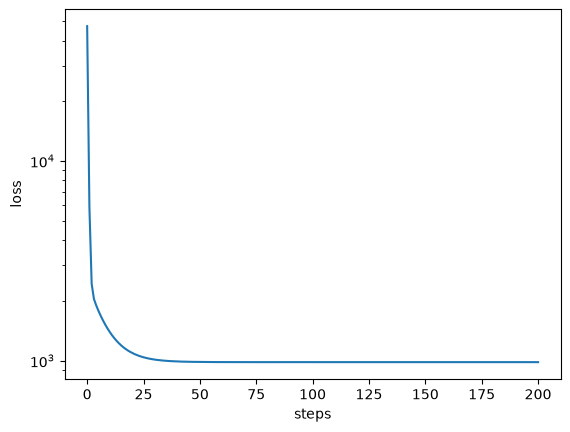

In [26]:
loss = opt["history"]["loss"]

plt.plot(loss)
plt.xlabel("steps")
plt.ylabel("loss")
plt.yscale("log") 

plt.show()

Detailed plot for the last few epochs.

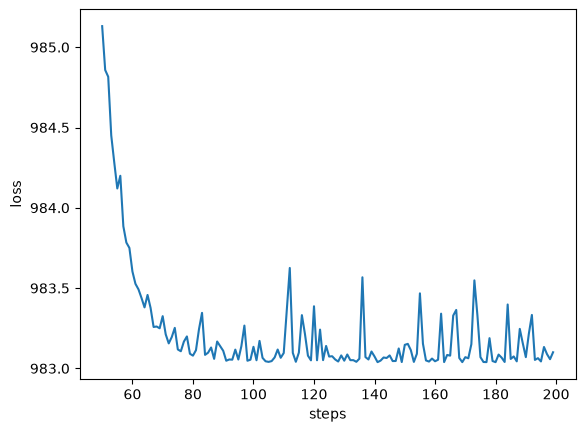

In [27]:
steps = range(50, 200)
loss_slice = opt["history"]["loss"].iloc[50:200]

plt.plot(steps, loss_slice)
plt.xlabel("steps")
plt.ylabel("loss")

plt.show()

Learning path

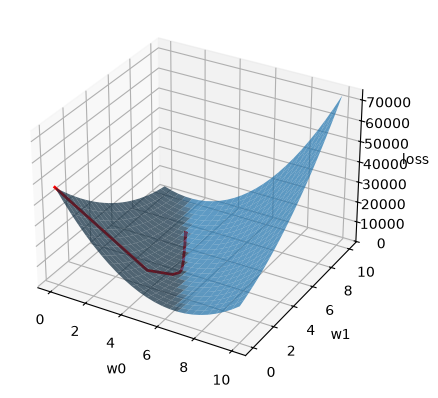

In [28]:
ax = loss_surface_plot(grid)

history = opt["history"]

ax.plot(
    history["w0"],
    history["w1"],
    history["loss"],
    color="red",
    linewidth=2
)

__Notes:__ 

* I used a very small batch size. Typical size are 32 or 64. 
* I used trial and error to find a good value for the learning rate $\alpha$.

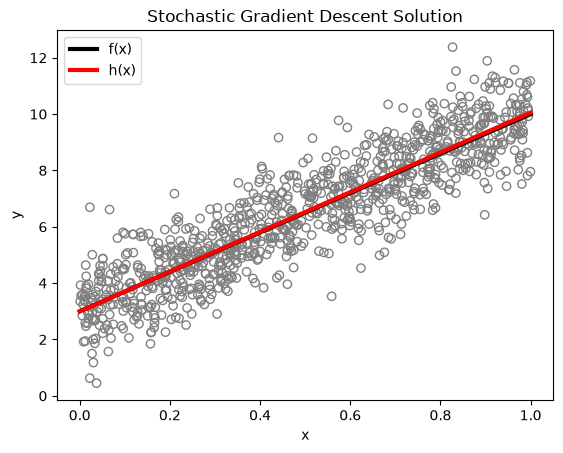

In [29]:
plot_data(xy, "Stochastic Gradient Descent Solution")

x_line = np.linspace(0, 1, 100)
y_line = y_hat(np.asarray(x_line), w0, w1)
plt.plot(x_line, y_line, color='red', linewidth=3, label='h(x)')

plt.legend()